# Continuous time dynamical approach to boolean satisfiability problems

## Example

Solution found
0.0025


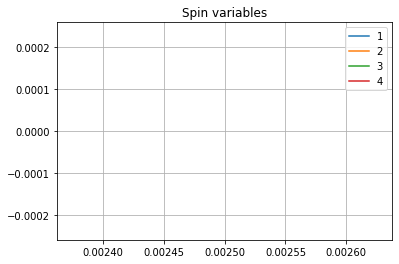

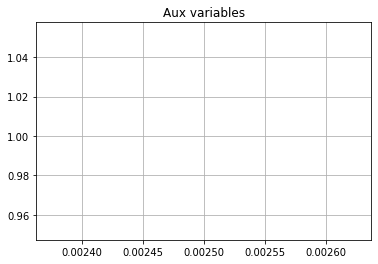

In [8]:
from pSAT_problem import CTDSolver, SATProblem, RK4, ForwardEuler

#cnf_file_name = 'E:\SAT_project\easy2.cnf'
cnf_file_name = 'E:\SAT_project\pySAT\generated_problems\sat_3_n4_cl6i597930.cnf'
#cnf_file_name = "E:\SAT_project\pySAT\easy_max_sat3_n4.cnf"
#sol = [False, False, True, True, True,True, True, True,True, True, False, False]

myProblem = SATProblem(cnf_file_name)
mIntegrator = RK4()
#mIntegrator = ForwardEuler()


solver = CTDSolver(myProblem, mIntegrator)
solver.solve()
solver.plot_traj()
solver.plot_aux()


In [ ]:
from pSAT_problem import CTDSolver, SATProblem, RK4

#cnf_file_name = 'E:\SAT_project\easy2.cnf'
cnf_file_name = "E:\SAT_project\pySAT\easy_max_sat3_n5.cnf"
#sol = [False, False, True, True, True,True, True, True,True, True, False, False]

myProblem = SATProblem(cnf_file_name)
mIntegrator = RK4()

solvers = []
for i in range(2):
    solver = CTDSolver(myProblem, mIntegrator)
    solver.solve(max_time=2.5, adaptive_flag = False)
    solvers.append(solver)


In [ ]:
#Requires non adaptive flag
dMatt = []
for i, solver_i in enumerate(solvers):
    row = []
    for j, solver_j in enumerate(solvers):
        if j > i:
            s_diffs = [ solver_i.traj[k]-solver_j.traj[k] for k in range(len(solver_i.times))]
            aux_diffs = [ solver_i.aux[k]-solver_j.aux[k] for k in range(len(solver_i.times))]
            row.append((s_diffs, aux_diffs, solver_i.times))
        else:
            row.append(None)
            
    dMatt.append(row)

In [ ]:
import matplotlib.pyplot as plt
ts = 0
tl = 2

for coordinate in range(len(dMatt[ts][tl][0][0])):
    plt.grid(True)
    plt.title("The difference between coordinate " +str(coordinate)+ " of simulations:" +str(ts)+"," +str(tl))
    x = [vec for vec in dMatt[ts][tl][2]]
    y = [abs(vec[coordinate]) for vec in dMatt[ts][tl][0]]
    y = [vec[coordinate] for vec in dMatt[ts][tl][0]]
    plt.scatter(x, y)
    plt.show()

## Generating full problems

In [ ]:
import itertools

clause_length = 3
number_of_variables = 5
number_of_clauses = 0

clauses = ""
for subset in itertools.combinations(range(1,2*number_of_variables+1), clause_length):
    clause = []
    for elem in subset:
        if elem > number_of_variables:
            clause.append(-elem+number_of_variables)
        else:
            clause.append(elem)
    valid = True
    for elem in clause:#not allowing both negated and non-negated to appear
        if elem in clause and -elem in clause:
            valid = False
    if valid:
        mstr = ""
        for element in clause:
            mstr += str(element) + " "
        mstr += "0\n"
        clauses += mstr
        number_of_clauses += 1

with open("easy_max_sat" + str(clause_length) +"_n"+str(number_of_variables)+".cnf", 'w') as file:
    file.write("p cnf " + str(number_of_variables) + " " + str(number_of_clauses)+ "\n")
    file.writelines(clauses)

In [11]:
import itertools

clause_length = 3
number_of_variables = 4
number_of_clauses = 16

clauses = []
for subset in itertools.combinations(range(1,2*number_of_variables+1), clause_length):
    clause = []
    for elem in subset:
        if elem > number_of_variables:
            clause.append(-elem+number_of_variables)
        else:
            clause.append(elem)
    valid = True
    for elem in clause:#not allowing both negated and non-negated to appear
        if elem in clause and -elem in clause:
            valid = False
    if valid:
         clauses.append(clause)

print(len(clauses))

valid_problems = []
for problem in itertools.combinations(clauses, number_of_clauses):
    #Ha egy válltozó csak negált vagy csak normál alakban szerepel akkor az redukálható probléma
    valid = True
    for variable in range(1, number_of_variables+1):
        only_as_negated = True
        only_in_normal_form = True
        not_in_any_clause = True
        for clause in problem:
            if variable in clause:
                only_as_negated = False
                not_in_any_clause = False
            if -1*variable in clause:
                only_in_normal_form = False
                not_in_any_clause = False
        if only_as_negated and not not_in_any_clause:
            valid = False
            #print("Not a valid prob. because " + str(variable) + " appear only negated")
            #print(problem)
            break
        if only_in_normal_form and not not_in_any_clause:
            valid = False
            #print("Not a valid prob. because " + str(variable) + " appear only in normal form")
            #print(problem)
            break
        if not_in_any_clause:
            valid = False
            #print("Not a valid prob. because " + str(variable) + " does not appear")
            #print(problem)
            break
    if valid:
        valid_problems.append(problem)

#Prume valid problems
for problem1 in valid_problems:
    for problem2 in valid_problems:
        #if every clause permuted in problem1 with perumtation P is the same as th clauses in problem2 they are the same
        pass

print(len(valid_problems))


32


KeyboardInterrupt: 

In [3]:
for i, problem in enumerate(valid_problems):
    if i%30 == 0:
        file_name = "sat_"+str(clause_length) +"_n"+str(number_of_variables)+"_cl"+ str(len(problem)) +"i"+ str(i) +".cnf"
        with open("e:\SAT_project\pySAT\generated_problems\\" +file_name, 'w') as file:
            file.write("p cnf " + str(number_of_variables) + " " + str(len(problem))+ "\n")
            for clause in problem:
                for variable in clause:
                    file.write( str(variable) + " ")
                file.write('0\n')

## Finding chaos

In [ ]:
from math import sqrt, pi
import numpy as np
import matplotlib.pyplot as plt

mySetp = lambda phi, theta : ( (phi + theta)%(2*pi), (theta + sqrt(2)/2)%(2*pi) )

line = [(0, x) for x in np.linspace(0.0, 2*pi, 25)]
iterated_lines = []
for i in range(10):
    new_line = []
    for mPoint in line:
        new_line.append( mySetp(*mPoint) )
    line = new_line
    iterated_lines.append(line)


In [ ]:
from matplotlib.pyplot import cm
colors = cm.rainbow(np.linspace(0,1,10))
for line, c in zip(iterated_lines, colors):
    plt.scatter([x[1] for x in line], [x[0] for x in line], c=c)
plt.show()

In [ ]:
from pSAT_problem import CTDSolver, SATProblem, RK4, ForwardEuler
#from scipy import linalg
import numpy as np
import matplotlib.pyplot as plt

cnf_file_name = 'E:\SAT_project\pySAT\generated_problems\sat_3_n4_cln5i34100.cnf'

myProblem = SATProblem(cnf_file_name)
mIntegrator = RK4()

points = []
for T in np.linspace(0.01, 0.4, 20):
    Dzsiiz = []
    for i in range(100):
        solver = CTDSolver(myProblem, mIntegrator)
        solver.solve_upto(T)
        if np.linalg.norm(solver.s) <= 0.99:
            Dzsiiz.append( np.prod(np.linalg.eigvals(solver.M)) )
    points.append( (T, sum(Dzsiiz)/len(Dzsiiz)) )



In [ ]:
plt.grid(True)
plt.title('Valami')
plt.plot( [asdf[0] for asdf in points], [np.log(asdf[1]) for asdf in points])
plt.show()

## Comparison of integration schemes

In [ ]:
from pSAT_problem import CTDSolver, SATProblem, RK4, ForwardEuler

cnf_file_name = 'E:\SAT_project\easy2.cnf'
#cnf_file_name = "E:\SAT_project\pySAT\easy_max_sat3_n5.cnf"

myProblem = SATProblem(cnf_file_name)
runge_kutta_integrator = RK4()
feuler_integrator = ForwardEuler()
rkSolvers = []
feulerSolvers = []
rkSolversA = []
feulerSolversA = []
for i in range(20):
    solver1 = CTDSolver(myProblem, runge_kutta_integrator)
    solver2 = CTDSolver(myProblem, feuler_integrator)
    solver3 = CTDSolver(myProblem, runge_kutta_integrator)
    solver4 = CTDSolver(myProblem, feuler_integrator)
    solver1.solve(max_time=1.5, adaptive_flag = False)
    solver2.solve(max_time=1.5, adaptive_flag = False)
    solver3.solve(max_time=1.5, adaptive_flag = True)
    solver4.solve(max_time=1.5, adaptive_flag = True)
    rkSolvers.append(solver1)
    feulerSolvers.append(solver2)
    rkSolversA.append(solver3)
    feulerSolversA.append(solver4)

In [ ]:
print('Discrete steps needed for RK4 method')
print( sum([len(x.times) for x in rkSolvers ]) )
print('Discrete steps needed for Euler method')
print( sum([len(x.times) for x in feulerSolvers ]) )
print('Discrete steps needed for adaptive RK4 method')
print( sum([len(x.times) for x in rkSolversA ]) )
print('Discrete steps needed for adaptive Euler method')
print( sum([len(x.times) for x in feulerSolversA ]) )
print('Virtual time needed for RK4 method')
print( sum([x.time for x in rkSolvers ]) )
print('Virtual time needed for Euler method')
print( sum([x.time for x in feulerSolvers ]) )
print('Virtual time needed for adaptive RK4 method')
print( sum([x.time for x in rkSolversA ]) )
print('Virtual time needed for adaptive Euler method')
print( sum([x.time for x in feulerSolversA ]) )
    